In [1]:
from fileIO import *
from constants import *
import numpy as np
import matplotlib.pyplot as plt

sim1d = CuDiscModel("../outputs/isoPD_1D_test")

# Load in grids, densities and temperatures

g = sim1d.grid
sizes1d = sim1d.load_grain_sizes()
gas1d, dust1d = sim1d.load_all_prim_data()
temp1d = sim1d.load_all_temp_data()
ts = sim1d.load_output_times()

sim2d = CuDiscModel("../outputs/isoPD2D_1D_test")

sizes2d = sim2d.load_grain_sizes()
gas2d, dust2d = sim2d.load_all_prim_data()
temp2d = sim2d.load_all_temp_data()

/u/srwmills/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/u/srwmills/cuDisc/codes/python/fileIO.py:134: RuntimeWarning: invalid value encountered in divide
  D = np.log(mass[1:]/mass[:-1])/np.log(size[1:]/size[:-1])


/tmp/ipykernel_9015/1168925520.py:6: RuntimeWarning: divide by zero encountered in log10
  cong = ax[i,1].contourf(g.R/au, g.Z/au, np.log10(dust2d.rho[i,:,:,0]), np.linspace(-27,-14,50), extend='both')


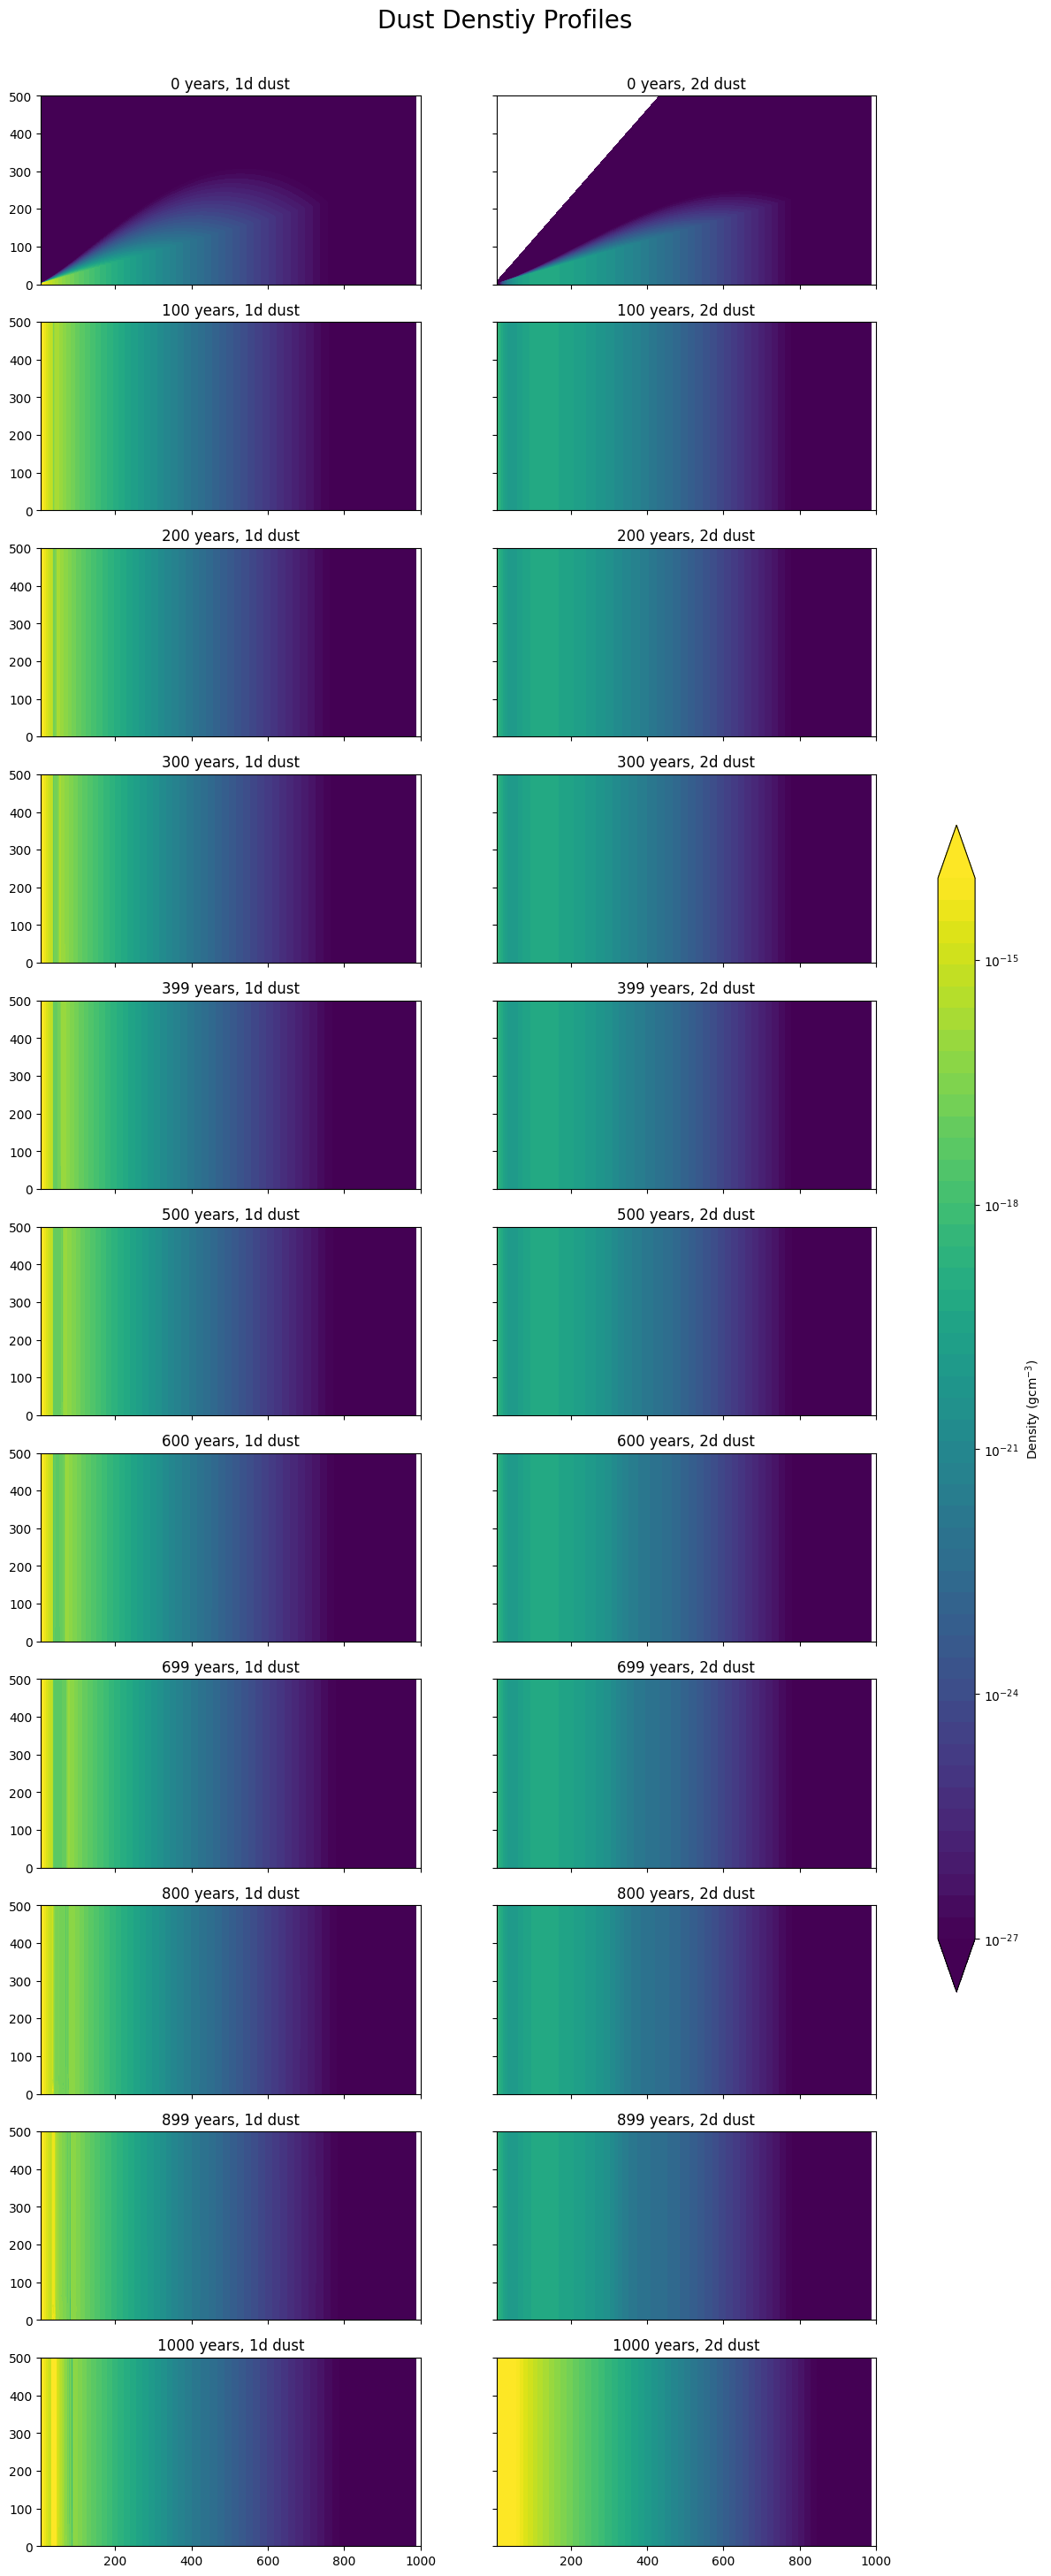

/tmp/ipykernel_9015/1168925520.py:27: RuntimeWarning: divide by zero encountered in log10
  con = ax[i].contourf(g.R/au, g.Z/au, np.log10(ratios[i,:,:,0]), np.linspace(0, 6, 50), extend='both')
/tmp/ipykernel_9015/1168925520.py:34: UserWarning: Adding colorbar to a different Figure <Figure size 1400x3300 with 23 Axes> than <Figure size 700x5500 with 12 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(cond, cax=cbar_ax)


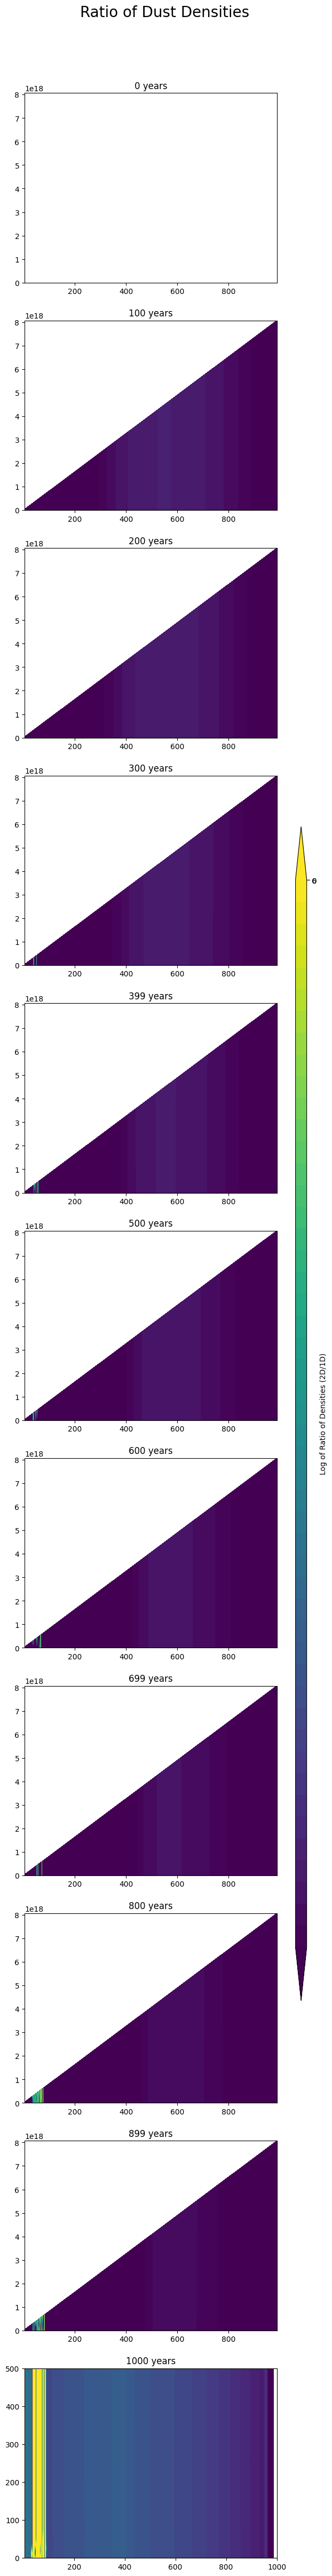

(11, 504, 5)


In [ ]:
fig, ax = plt.subplots(len(ts), 2, figsize=(14, 3*np.size(ts)), sharex=True, sharey=True)

for i in range(0, len(ts)):
    cond = ax[i,0].contourf(g.R/au, g.Z/au, np.log10(dust1d.rho[i,:,:,0]), np.linspace(-27,-14,50), extend='both')
    ax[i,0].set_title('%1.0d years, 1d dust'%(ts[i]//year))
    cong = ax[i,1].contourf(g.R/au, g.Z/au, np.log10(dust2d.rho[i,:,:,0]), np.linspace(-27,-14,50), extend='both')
    ax[i,1].set_title('%1.0d years, 2d dust'%(ts[i]//year))

plt.xlim(5,1000)
plt.ylim(0,500)
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.3, 0.03, 0.4])
cbar = fig.colorbar(cond, cax=cbar_ax)
cbar.set_ticks(np.arange(-27,-12,3))
cbar.set_ticklabels(["$10^{%d}$"%(x) for x in np.arange(-27,-12,3)])
cbar.set_label(r"Density (gcm$^{-3}$)")
fig.subplots_adjust(top=0.95)
fig.suptitle("Dust Denstiy Profiles", size=20)

plt.show()

ratios = dust2d.rho / dust1d.rho

fig, ax = plt.subplots(len(ts), 1, figsize=(7, 5*len(ts)))

for i in range(len(ts)):
    con = ax[i].contourf(g.R/au, g.Z/au, np.log10(ratios[i,:,:,0]), np.linspace(0, 6, 50), extend='both')
    ax[i].set_title('%1.0d years'%(ts[i]//year))

plt.xlim(5,1000)
plt.ylim(0,500)
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.3, 0.03, 0.4])
cbar = fig.colorbar(cond, cax=cbar_ax)
cbar.set_ticks(np.linspace(0,6,num=2,endpoint=True))
cbar.set_label(r"Log of Ratio of Densities (2D/1D)")
fig.subplots_adjust(top=0.95)
fig.suptitle("Ratio of Dust Densities", size=20)

plt.show()

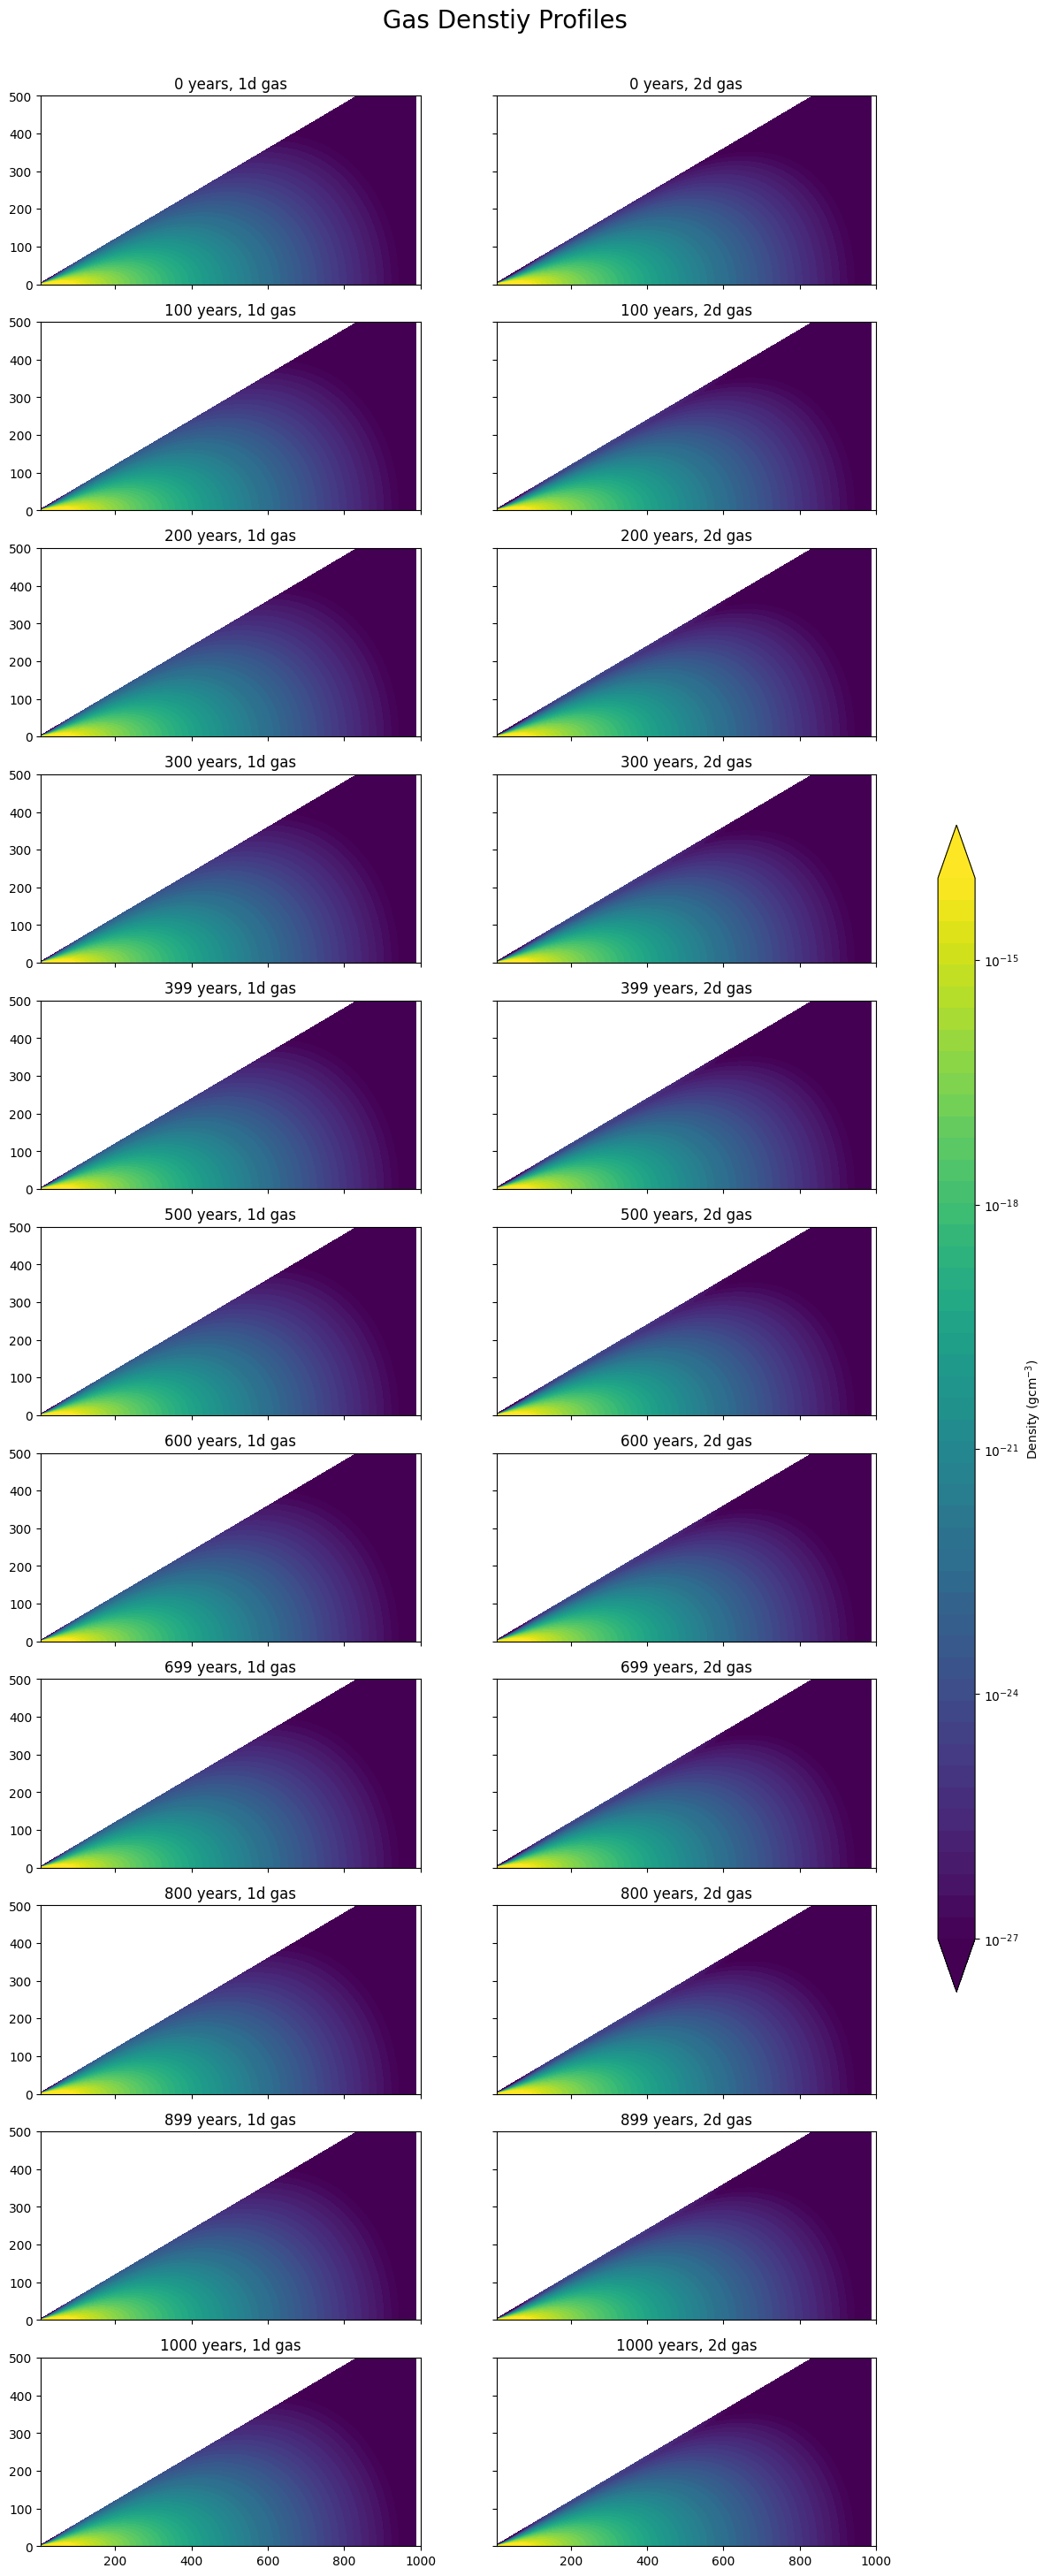

/tmp/ipykernel_9015/1217573748.py:34: UserWarning: Adding colorbar to a different Figure <Figure size 1400x3300 with 23 Axes> than <Figure size 700x5500 with 12 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(cond, cax=cbar_ax)


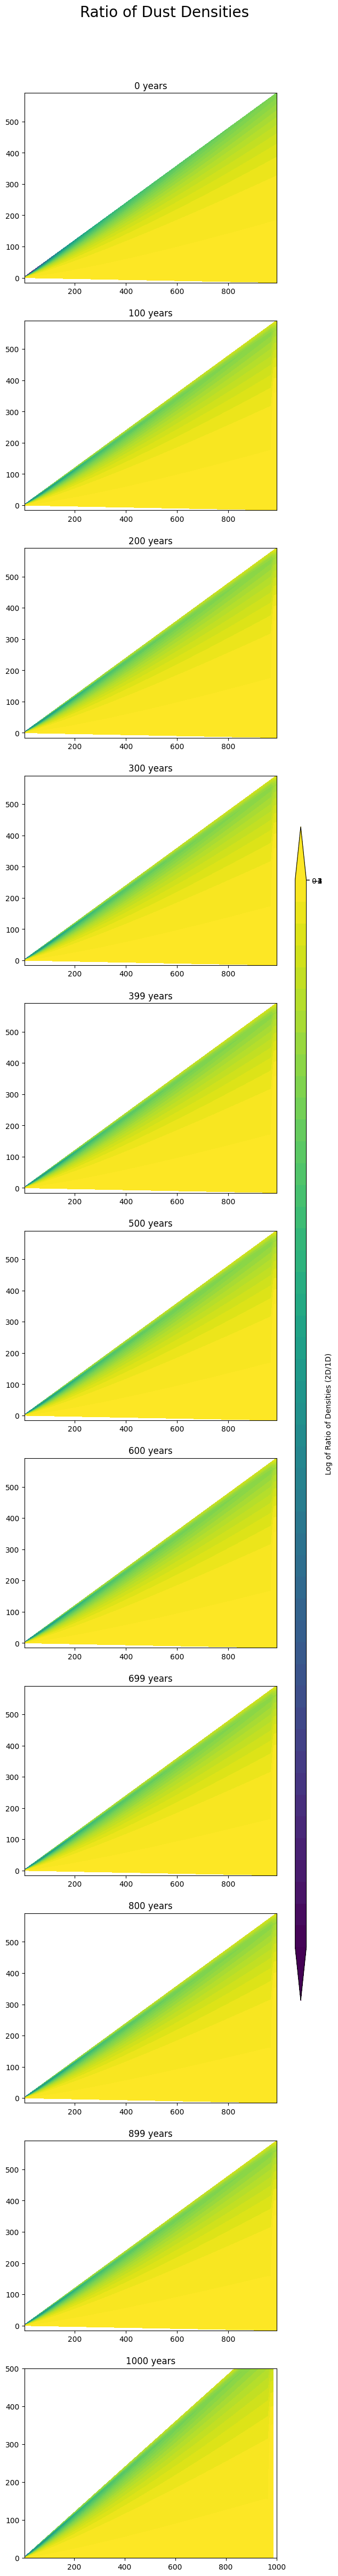

In [13]:
fig, ax = plt.subplots(len(ts), 2, figsize=(14, 3*np.size(ts)), sharex=True, sharey=True)

for i in range(0, len(ts)):
    cond = ax[i,0].contourf(g.R/au, g.Z/au, np.log10(gas1d.rho[i,:,:]), np.linspace(-27,-14,50), extend='both')
    ax[i,0].set_title('%1.0d years, 1d gas'%(ts[i]//year))
    cong = ax[i,1].contourf(g.R/au, g.Z/au, np.log10(gas2d.rho[i,:,:]), np.linspace(-27,-14,50), extend='both')
    ax[i,1].set_title('%1.0d years, 2d gas'%(ts[i]//year))

plt.xlim(5,1000)
plt.ylim(0,500)
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.3, 0.03, 0.4])
cbar = fig.colorbar(cond, cax=cbar_ax)
cbar.set_ticks(np.arange(-27,-12,3))
cbar.set_ticklabels(["$10^{%d}$"%(x) for x in np.arange(-27,-12,3)])
cbar.set_label(r"Density (gcm$^{-3}$)")
fig.subplots_adjust(top=0.95)
fig.suptitle("Gas Denstiy Profiles", size=20)

plt.show()

ratios = gas2d.rho / gas1d.rho

fig, ax = plt.subplots(len(ts), 1, figsize=(7, 5*len(ts)))

for i in range(len(ts)):
    con = ax[i].contourf(g.R/au, g.Z/au, np.log10(ratios[i,:,:]), np.linspace(-4, 0, 50), extend='both')
    ax[i].set_title('%1.0d years'%(ts[i]//year))

plt.xlim(5,1000)
plt.ylim(0,500)
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.3, 0.03, 0.4])
cbar = fig.colorbar(cond, cax=cbar_ax)
cbar.set_ticks(np.linspace(-4,0,num=5,endpoint=True))
cbar.set_label(r"Log of Ratio of Densities (2D/1D)")
fig.subplots_adjust(top=0.95)
fig.suptitle("Ratio of Dust Densities", size=20)

plt.show()

In [11]:
simtest = CuDiscModel("../outputs/isoPD2D_1dvert")

# Load in grids, densities and temperatures

sizestest = simtest.load_grain_sizes()
gastest, dusttest = simtest.load_all_prim_data()
temptest = simtest.load_all_temp_data()

print(gastest.vphi[1,:,:])

[[1327181.28594166 1326437.95359349 1326437.95359349 1327181.28594166
  1327181.28594166 1327181.28594166]
 [1327181.28594166 1326437.95359349 1326437.95359349 1327181.28594166
  1327181.28594166 1327181.28594166]
 [1327181.28594166 1326437.95359349 1326729.40242368 1327358.27479464
  1327181.28594166 1327181.28594166]
 ...
 [  95759.81935749   95759.81941097   95759.81813152   95759.81814147
    95759.81935749   95759.81941097]
 [  95759.81935749   95759.81941097   95759.81941097   95759.81935749
    95759.81935749   95759.81941097]
 [  95759.81935749   95759.81941097   95759.81941097   95759.81935749
    95759.81935749   95759.81941097]]


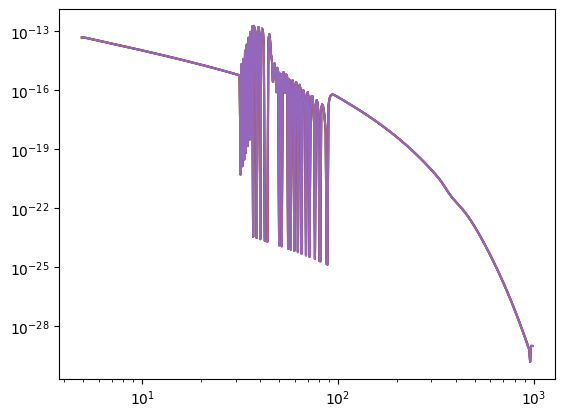

In [28]:
plt.loglog(g.R/au, dust1d.rho[-1,:,2,0])
plt.show()